# Data Cleaning & Preprocessing: Career Path Decision Tree Training Data

In [198]:
import pandas as pd

df = pd.read_csv('results.csv', low_memory=False)
print(f"Starting shape: {df.shape[0]} rows, {df.shape[1]} columns")

Starting shape: 49191 rows, 172 columns


Of the 172 raw columns in the survey export, most describe a **working developer's current job situation** -- salary, employer, remote work setup, tool opinions, and similar. A student building a roadmap has none of that information about themselves yet, so those columns are useless as prediction inputs. Only 8 columns describe things a student *can* actually provide about their own background and skills, so those are the only ones kept.

In [199]:
keep_cols = [
    'MainBranch', 'EdLevel', 'YearsCode', 'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith', 'DevType',
]

dropped_count = df.shape[1] - len(keep_cols)
df = df[keep_cols]
print(f"Columns kept: {len(keep_cols)}, columns dropped: {dropped_count}")

Columns kept: 8, columns dropped: 164


Only respondents who answered `MainBranch == "I am a developer by profession"` give a real skill-to-role mapping -- they actually work in the role their skills led them to. Students, hobbyists, and retired respondents would add noise rather than signal, since their DevType/skill relationship isn't the kind of career outcome this tool wants to predict.

In [200]:
before = len(df)
df = df[df['MainBranch'] == 'I am a developer by profession']
after = len(df)
print(f"Rows before: {before}, rows after: {after}")

Rows before: 49191, rows after: 37467


Five `DevType` categories aren't valid targets for a roadmap tool to recommend a student toward:
- **Student** -- circular, it's not a career outcome
- **Retired** -- not a role to grow into
- **Senior executive (C-suite, VP, etc.)** -- reached via tenure, not a skill profile
- **Founder, technology or otherwise** -- same issue, and too vague as a category
- **Other (please specify):** -- undefined, no consistent skill signal

These rows are dropped.

In [201]:
invalid_devtypes = [
    'Student',
    'Retired',
    'Senior executive (C-suite, VP, etc.)',
    'Founder, technology or otherwise',
    'Other (please specify):',
]

before = len(df)
removed_mask = df['DevType'].isin(invalid_devtypes)
removed_present = sorted(df.loc[removed_mask, 'DevType'].unique().tolist())
df = df[~removed_mask]
after = len(df)
print(f"Rows before: {before}, rows after: {after}")
print(f"Categories removed: {removed_present}")

Rows before: 37467, rows after: 35546
Categories removed: ['Founder, technology or otherwise', 'Other (please specify):', 'Retired', 'Senior executive (C-suite, VP, etc.)', 'Student']


`EdLevel`'s "Other (please specify):" response can't be placed on an ordinal education scale -- there's no way to know where it falls relative to the other levels. Those rows are dropped too.

In [202]:
before = len(df)
df = df[df['EdLevel'] != 'Other (please specify):']
after = len(df)
print(f"Rows before: {before}, rows after: {after}")

Rows before: 35546, rows after: 35200


This step takes a **complete-case** approach: any row missing a value in one of the 6 feature columns or `DevType` is dropped, rather than imputing a value. The dataset is large enough that this doesn't meaningfully hurt the sample size, and imputing categorical skill/education data would risk inventing signal that isn't really there.

In [203]:
required_cols = [
    'EdLevel', 'YearsCode', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevType',
]

before = len(df)
df = df.dropna(subset=required_cols)
after = len(df)
print(f"Rows before: {before}, rows after: {after}")

Rows before: 35200, rows after: 14208


`DevType` classes with too few examples can't be reliably learned or evaluated on -- a decision tree (and any train/test split) needs enough examples per class to find a pattern and to check it. A **50-example minimum** keeps every major technical career path while dropping classes too small to mean anything statistically.

In [204]:
before = len(df)
class_counts = df['DevType'].value_counts()
small_classes = class_counts[class_counts < 50].index.tolist()

df = df[~df['DevType'].isin(small_classes)]
after = len(df)

print(f"Rows before: {before}, rows after: {after}")
print(f"Final class count: {df['DevType'].nunique()}")
print(f"Classes dropped (< 50 rows): {small_classes}")
print("\nRemaining class distribution:")
print(df['DevType'].value_counts())

Rows before: 14208, rows after: 14018
Final class count: 18
Classes dropped (< 50 rows): ['Project manager', 'Applied scientist', 'System administrator', 'Support engineer or analyst', 'Database administrator or engineer', 'Product manager', 'Data or business analyst', 'Financial analyst or engineer', 'UX, Research Ops or UI design professional']

Remaining class distribution:
DevType
Developer, full-stack                            6665
Developer, back-end                              2969
Architect, software or solutions                 1191
Developer, front-end                              546
Developer, desktop or enterprise applications     492
Engineering manager                               413
DevOps engineer or professional                   350
Data engineer                                     250
Developer, mobile                                 227
AI/ML engineer                                    206
Developer, embedded applications or devices       128
Cloud infrastructu

`YearsCode` has implausible outliers -- some respondents entered 100, and this shows up across every age bracket including 18-24 year olds, which clearly isn't a real answer. Rather than build a complex per-respondent validation against age, this caps `YearsCode` at **40 years** as a simple, defensible senior-career ceiling.

In [205]:
print("YearsCode summary before capping:")
print(df['YearsCode'].describe())

df['YearsCode'] = df['YearsCode'].clip(upper=40)

print("\nYearsCode summary after capping:")
print(df['YearsCode'].describe())

YearsCode summary before capping:
count    14018.000000
mean        17.588101
std         10.285799
min          1.000000
25%         10.000000
50%         15.000000
75%         25.000000
max        100.000000
Name: YearsCode, dtype: float64

YearsCode summary after capping:
count    14018.000000
mean        17.447425
std          9.909823
min          1.000000
25%         10.000000
50%         15.000000
75%         25.000000
max         40.000000
Name: YearsCode, dtype: float64


`EdLevel` gets an **ordinal encoding**, specifically -- unlike the skill columns, it has a real order (doctorate > master's > bachelor's > ...). Mapping it to a single numeric column (1-7) preserves that order and lets the decision tree ask one meaningful threshold question (e.g. "EdLevel >= 5?"), rather than one-hot exploding it into 7 unordered columns that hide the ranking.

In [206]:
edlevel_map = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
}

sample_before = df[['EdLevel']].sample(5, random_state=42).copy()
df['EdLevel'] = df['EdLevel'].map(edlevel_map)
sample_after = df.loc[sample_before.index, 'EdLevel']

comparison = sample_before.copy()
comparison['EdLevel_encoded'] = sample_after
print(comparison)
print(f"\nUnmapped (NaN) values after mapping: {df['EdLevel'].isna().sum()}")

                                               EdLevel  EdLevel_encoded
16669     Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
2363   Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
37316     Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
14212     Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
12228     Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5

Unmapped (NaN) values after mapping: 0


The 4 skill columns (`LanguageHaveWorkedWith`, `DatabaseHaveWorkedWith`, `PlatformHaveWorkedWith`, `WebframeHaveWorkedWith`) get **multi-hot encoding**. These are semicolon-joined multi-select checkbox answers -- not ordered, and not mutually exclusive (a respondent can know both Python and Java). Each possible skill becomes its own binary column via `str.get_dummies(sep=';')`, prefixed with the original column name so the source is traceable.

In [207]:
skill_cols = [
    'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith',
]

for col in skill_cols:
    dummies = df[col].str.get_dummies(sep=';')
    dummies = dummies.add_prefix(f"{col}__")
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(columns=[col])

print(f"Final shape after multi-hot encoding: {df.shape}")

Final shape after multi-hot encoding: (14018, 146)


The dataset is now fully numeric and ready for a CART decision tree. No scaling is needed -- tree splits are threshold-based ("is this value <= X?") and scale-invariant, unlike distance-based or gradient-based models.

`MainBranch` was only used earlier as a **filter** (Cell 6, keeping only "I am a developer by profession" rows) -- it was never meant to be a feature. Since that filter left every remaining row with the identical value, the column is now constant and carries zero information for the tree to split on. It's dropped here, right before the final save.

In [208]:
print(f"Columns before drop: {df.shape[1]}")
df = df.drop(columns=['MainBranch'])
print(f"Columns after drop: {df.shape[1]}")

Columns before drop: 146
Columns after drop: 145


In [209]:
print(f"Final shape: {df.shape}")
print(f"\nFinal DevType class count: {df['DevType'].nunique()}")
print("Final DevType distribution:")
print(df['DevType'].value_counts())

total_missing = df.isna().sum().sum()
print(f"\nTotal missing values remaining: {total_missing}")
assert total_missing == 0, "Missing values remain!"

df.to_csv('training_data_final.csv', index=False)
print("\nSaved to training_data_final.csv")

Final shape: (14018, 145)

Final DevType class count: 18
Final DevType distribution:
DevType
Developer, full-stack                            6665
Developer, back-end                              2969
Architect, software or solutions                 1191
Developer, front-end                              546
Developer, desktop or enterprise applications     492
Engineering manager                               413
DevOps engineer or professional                   350
Data engineer                                     250
Developer, mobile                                 227
AI/ML engineer                                    206
Developer, embedded applications or devices       128
Cloud infrastructure engineer                     128
Data scientist                                    109
Academic researcher                                84
Developer, AI apps or physical AI                  79
Cybersecurity or InfoSec professional              63
Developer, QA or test                      

A **stratified train/test split** must happen before anything else in building the tree -- specifically before computing class weights, since weights need to come from the training set's class counts only. Splitting after weighting would let information about the test set's distribution leak into training.

"Stratified" means each class keeps its proportion in both the train and test sets. This matters here because the smallest class (`Developer, game or graphics`, 55 rows) could otherwise land almost entirely in one set by chance with a plain random split -- a stratified split guarantees roughly 80% of it lands in train and 20% in test, same as every other class.

In [210]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('training_data_final.csv', low_memory=False)

X = data.drop(columns=['DevType'])
y = data['DevType']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

proportions = pd.DataFrame({
    'train_pct': y_train.value_counts(normalize=True) * 100,
    'test_pct': y_test.value_counts(normalize=True) * 100,
}).sort_values('train_pct', ascending=False)

print("\nClass proportions, train vs test (%):")
print(proportions.round(2))

X_train shape: (11214, 144)
X_test shape: (2804, 144)

Class proportions, train vs test (%):
                                               train_pct  test_pct
DevType                                                           
Developer, full-stack                              47.55     47.54
Developer, back-end                                21.18     21.18
Architect, software or solutions                    8.50      8.49
Developer, front-end                                3.90      3.89
Developer, desktop or enterprise applications       3.51      3.50
Engineering manager                                 2.94      2.96
DevOps engineer or professional                     2.50      2.50
Data engineer                                       1.78      1.78
Developer, mobile                                   1.62      1.60
AI/ML engineer                                      1.47      1.46
Developer, embedded applications or devices         0.91      0.93
Cloud infrastructure engineer       

**Class weighting** corrects for the class imbalance visible above -- with `Developer, full-stack` at 6,665 rows and `Developer, game or graphics` at 55, an unweighted tree would learn to favor predicting full-stack whenever uncertain, since that minimizes error on the training data even while ignoring the small classes entirely.

Weighting each class **inversely to its frequency** (computed from `y_train` only, so no test-set information leaks in) means a misclassified example from a rare class costs more than one from a common class -- this is what the Gini/entropy impurity calculation will use in the next step to build the tree.

In [211]:
class_counts_train = y_train.value_counts()
num_classes = len(class_counts_train)

class_weights = {
    cls: len(y_train) / (num_classes * count)
    for cls, count in class_counts_train.items()
}

sorted_weights = dict(sorted(class_weights.items(), key=lambda kv: kv[1], reverse=True))

print("Class weights (highest to lowest):")
for cls, w in sorted_weights.items():
    print(f"  {cls:55s} {w:.4f}")

Class weights (highest to lowest):
  Developer, game or graphics                             14.1591
  Cybersecurity or InfoSec professional                   12.4600
  Developer, QA or test                                   12.2157
  Developer, AI apps or physical AI                       9.8889
  Academic researcher                                     9.2985
  Data scientist                                          7.1609
  Developer, embedded applications or devices             6.1078
  Cloud infrastructure engineer                           6.1078
  AI/ML engineer                                          3.7758
  Developer, mobile                                       3.4231
  Data engineer                                           3.1150
  DevOps engineer or professional                         2.2250
  Engineering manager                                     1.8879
  Developer, desktop or enterprise applications           1.5812
  Developer, front-end                              

**Gini impurity**, in plain terms, is a number from 0 to just under 1 measuring how "mixed up" a group of labels is. 0 means every example in the group is the same class (perfectly pure). Higher means more mixed -- a group evenly split across many classes has impurity close to 1. The tree's whole job at each step is finding a question that splits a mixed group into two less-mixed groups.

Since class weights were computed in the previous step, this uses the **weighted** version: a mistake involving a rare class should count for more than one involving a common class, so impurity is calculated using weighted class proportions, not raw counts.

In [212]:
import numpy as np

def gini_impurity(y, sample_weights):
    total = sample_weights.sum()
    if total == 0:
        return 0.0
    _, inv = np.unique(y, return_inverse=True)
    class_weight_sums = np.bincount(inv, weights=sample_weights)
    proportions = class_weight_sums / total
    return 1.0 - np.sum(proportions ** 2)

sample_weights_train = y_train.map(class_weights).to_numpy()
y_train_arr = y_train.to_numpy()

full_impurity = gini_impurity(y_train_arr, sample_weights_train)
print(f"Gini impurity of full y_train (18 mixed classes): {full_impurity:.4f}")

single_class_mask = y_train_arr == 'Developer, full-stack'
single_class_impurity = gini_impurity(
    y_train_arr[single_class_mask], sample_weights_train[single_class_mask]
)
print(f"Gini impurity of a single-class subset (Developer, full-stack only): {single_class_impurity:.4f}")

Gini impurity of full y_train (18 mixed classes): 0.9444
Gini impurity of a single-class subset (Developer, full-stack only): 0.0000


**Finding the best split** means trying each feature, and for each feature, trying candidate threshold values, asking: "if I split the data into `<= threshold` and `> threshold`, how much less mixed are the two resulting groups compared to before?" The split that reduces impurity the most (weighted by how large each resulting group is) gets chosen.

Binary skill columns only need one threshold (0.5, i.e. has the skill or doesn't), while `YearsCode` and `EdLevel` need multiple candidate thresholds tried, since they're not binary -- the candidates tried are the midpoints between sorted unique values actually present in the current data.

In [213]:
def best_split(X, y, sample_weights, feature_list):
    total_weight = sample_weights.sum()
    base_impurity = gini_impurity(y, sample_weights)
    best_feature, best_threshold, best_reduction = None, None, 0.0

    for j, feat in enumerate(feature_list):
        col = X[:, j]
        uniq = np.unique(col)
        if uniq.size < 2:
            continue
        if uniq.size == 2 and set(uniq.tolist()) == {0, 1}:
            thresholds = np.array([0.5])
        else:
            thresholds = (uniq[:-1] + uniq[1:]) / 2.0

        for t in thresholds:
            left_mask = col <= t
            left_w = sample_weights[left_mask].sum()
            right_w = total_weight - left_w
            if left_w == 0 or right_w == 0:
                continue
            left_impurity = gini_impurity(y[left_mask], sample_weights[left_mask])
            right_impurity = gini_impurity(y[~left_mask], sample_weights[~left_mask])
            weighted_impurity = (left_w * left_impurity + right_w * right_impurity) / total_weight
            reduction = base_impurity - weighted_impurity
            if reduction > best_reduction:
                best_reduction = reduction
                best_feature = feat
                best_threshold = t

    return best_feature, best_threshold, best_reduction

feature_list = list(X_train.columns)
X_train_arr = X_train[feature_list].to_numpy(dtype=float)

root_feature, root_threshold, root_reduction = best_split(
    X_train_arr, y_train_arr, sample_weights_train, feature_list
)
print(f"Root split: {root_feature} <= {root_threshold}, impurity reduction = {root_reduction:.4f}")

Root split: LanguageHaveWorkedWith__Swift <= 0.5, impurity reduction = 0.0119


**Recursive tree building**: after finding the best split for a group, do the same thing again separately on each of the two resulting groups, and keep going. Three stopping conditions end the recursion, each existing to prevent an overfit tree that just memorizes the training data:

- **`max_depth`** -- don't go deeper than N levels
- **`min_samples_split`** -- don't split a group with fewer than N examples left
- **purity** -- if a group is already 0 impurity, there's nothing left to split

When recursion stops, that becomes a **leaf**, storing the weighted class distribution of whatever examples ended up there.

In [214]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, class_distribution=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.class_distribution = class_distribution

    def is_leaf(self):
        return self.class_distribution is not None


def leaf_distribution(y, sample_weights):
    total = sample_weights.sum()
    dist = {}
    for cls in np.unique(y):
        dist[cls] = sample_weights[y == cls].sum() / total
    return dist


def build_tree(X, y, sample_weights, feature_list, depth=0, max_depth=12, min_samples_split=10):
    if depth >= max_depth or len(y) < min_samples_split or gini_impurity(y, sample_weights) == 0:
        return Node(class_distribution=leaf_distribution(y, sample_weights))

    feature, threshold, reduction = best_split(X, y, sample_weights, feature_list)
    if feature is None or reduction <= 0:
        return Node(class_distribution=leaf_distribution(y, sample_weights))

    j = feature_list.index(feature)
    left_mask = X[:, j] <= threshold
    right_mask = ~left_mask

    left_child = build_tree(X[left_mask], y[left_mask], sample_weights[left_mask],
                             feature_list, depth + 1, max_depth, min_samples_split)
    right_child = build_tree(X[right_mask], y[right_mask], sample_weights[right_mask],
                              feature_list, depth + 1, max_depth, min_samples_split)

    return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)


tree = build_tree(X_train_arr, y_train_arr, sample_weights_train, feature_list)


def tree_stats(node, depth=0):
    if node.is_leaf():
        return depth, 1
    left_depth, left_leaves = tree_stats(node.left, depth + 1)
    right_depth, right_leaves = tree_stats(node.right, depth + 1)
    return max(left_depth, right_depth), left_leaves + right_leaves


max_depth_reached, num_leaves = tree_stats(tree)
print(f"Max depth reached: {max_depth_reached}")
print(f"Total leaf nodes: {num_leaves}")

Max depth reached: 12
Total leaf nodes: 554


A leaf's **class distribution** is not a single predicted label -- it's the weighted proportion of each of the 18 classes among the training examples that ended up at that leaf. This is exactly what produces a top-5 ranked list rather than one guess: sort that distribution and take the top 5.

In [215]:
def predict_proba(tree, sample, feature_list):
    node = tree
    while not node.is_leaf():
        j = feature_list.index(node.feature)
        value = sample[j]
        node = node.left if value <= node.threshold else node.right
    return node.class_distribution


X_test_arr = X_test[feature_list].to_numpy(dtype=float)
sample = X_test_arr[0]
true_label = y_test.iloc[0]

proba = predict_proba(tree, sample, feature_list)
top5 = sorted(proba.items(), key=lambda kv: kv[1], reverse=True)[:5]

print(f"True label: {true_label}\n")
print("Top 5 predicted classes:")
for cls, p in top5:
    marker = "  <-- true label" if cls == true_label else ""
    print(f"  {cls:55s} {p:.4f}{marker}")

True label: Developer, embedded applications or devices

Top 5 predicted classes:
  DevOps engineer or professional                         0.5200
  Developer, back-end                                     0.2452
  Architect, software or solutions                        0.1528
  Developer, full-stack                                   0.0819


**Evaluating the tree on the full test set.** The single-row check above only showed one example; the real question is how the tree performs across all 2,804 held-out test rows it never saw during training.

Since this is a top-5 recommendation tool rather than a single-label classifier, two metrics matter:
- **Top-1 accuracy** -- the single highest-probability class matches the true label. This is the strict, traditional metric.
- **Top-5 accuracy** -- the true label appears anywhere in the top 5 ranked classes. This is the metric that actually reflects how the tool will be used: a student sees 5 suggested paths, not 1, so this is the more meaningful number.

Both are computed by calling `predict_proba` on every row of `X_test` and comparing against `y_test`.

In [216]:
top1_correct = 0
top5_correct = 0

for i in range(len(X_test_arr)):
    sample = X_test_arr[i]
    true_label = y_test.iloc[i]

    proba = predict_proba(tree, sample, feature_list)
    ranked = sorted(proba.items(), key=lambda kv: kv[1], reverse=True)
    ranked_labels = [cls for cls, _ in ranked]

    if ranked_labels and ranked_labels[0] == true_label:
        top1_correct += 1
    if true_label in ranked_labels[:5]:
        top5_correct += 1

n_test = len(X_test_arr)
top1_accuracy = top1_correct / n_test
top5_accuracy = top5_correct / n_test

print(f"Test set size: {n_test}")
print(f"Top-1 accuracy: {top1_correct}/{n_test} = {top1_accuracy:.4f}")
print(f"Top-5 accuracy: {top5_correct}/{n_test} = {top5_accuracy:.4f}")

Test set size: 2804
Top-1 accuracy: 315/2804 = 0.1123
Top-5 accuracy: 1953/2804 = 0.6965


**Sanity-checking against sklearn's `DecisionTreeClassifier`.** The custom implementation above reimplements CART from scratch, so it's worth confirming it isn't silently wrong by comparing it to a battle-tested library under the *exact same conditions*: same `X_train`/`y_train` split, same `class_weight` dictionary, and the same `max_depth=12` / `min_samples_split=10` hyperparameters. If the two report similar top-1/top-5 accuracy, that's good evidence the from-scratch tree is behaving correctly rather than having a subtle bug that happens to still produce output.

In [217]:
from sklearn.tree import DecisionTreeClassifier

sk_tree = DecisionTreeClassifier(
    max_depth=12, min_samples_split=10, class_weight=class_weights, random_state=42
)
sk_tree.fit(X_train, y_train)

sk_proba = sk_tree.predict_proba(X_test)
sk_classes = sk_tree.classes_

sk_top1_correct = 0
sk_top5_correct = 0

for i in range(len(X_test)):
    true_label = y_test.iloc[i]
    ranked_idx = np.argsort(sk_proba[i])[::-1]
    ranked_labels = sk_classes[ranked_idx]

    if ranked_labels[0] == true_label:
        sk_top1_correct += 1
    if true_label in ranked_labels[:5]:
        sk_top5_correct += 1

sk_top1_accuracy = sk_top1_correct / n_test
sk_top5_accuracy = sk_top5_correct / n_test

print(f"sklearn Top-1 accuracy: {sk_top1_correct}/{n_test} = {sk_top1_accuracy:.4f}")
print(f"sklearn Top-5 accuracy: {sk_top5_correct}/{n_test} = {sk_top5_accuracy:.4f}")

print("\nCustom tree vs sklearn:")
print(f"  Top-1: {top1_accuracy:.4f} (custom) vs {sk_top1_accuracy:.4f} (sklearn)")
print(f"  Top-5: {top5_accuracy:.4f} (custom) vs {sk_top5_accuracy:.4f} (sklearn)")

sklearn Top-1 accuracy: 315/2804 = 0.1123
sklearn Top-5 accuracy: 1985/2804 = 0.7079

Custom tree vs sklearn:
  Top-1: 0.1123 (custom) vs 0.1123 (sklearn)
  Top-5: 0.6965 (custom) vs 0.7079 (sklearn)


**Sanity check: is the Swift root split real, or a bug?** The root split chosen earlier was `LanguageHaveWorkedWith__Swift <= 0.5` -- a somewhat surprising first question, since Swift is a relatively uncommon skill compared to something like JavaScript.

To check this isn't a bug, rerun the exact same `best_split` logic on the root (full `X_train`/`y_train`) but with every sample weight set to **1** (unweighted), and compare side by side against the already-known weighted result. If the unweighted version instead picks a common-language column (e.g. JavaScript) with a much larger impurity reduction, that confirms the weighted result is a real, explainable consequence of class weighting -- not a bug -- since weighting deliberately trades "resolve the biggest class fastest" for "treat all 18 classes as equally worth resolving."

In [218]:
uniform_weights = np.ones(len(y_train_arr))
unweighted_feature, unweighted_threshold, unweighted_reduction = best_split(
    X_train_arr, y_train_arr, uniform_weights, feature_list
)

print(f"{'':12s} {'Feature':45s} {'Threshold':>10s} {'Impurity Reduction':>20s}")
print(f"{'Weighted:':12s} {root_feature:45s} {str(root_threshold):>10s} {root_reduction:>20.4f}")
print(f"{'Unweighted:':12s} {unweighted_feature:45s} {str(unweighted_threshold):>10s} {unweighted_reduction:>20.4f}")

             Feature                                        Threshold   Impurity Reduction
Weighted:    LanguageHaveWorkedWith__Swift                        0.5               0.0119
Unweighted:  LanguageHaveWorkedWith__HTML/CSS                     0.5               0.0242


**Fixing leaves with fewer than 5 classes.** With 554 leaves across ~11,000 training rows, many leaves only contain a handful of the 18 classes -- so `predict_proba` can't always produce a real top-5 (the earlier single-row test only returned 4 classes for exactly this reason).

**The fix**: store the class distribution at **every** node during tree building, not just leaves -- a parent node's distribution is a superset of its children's training examples, so it's a reasonable fallback source. During prediction, track the full path of nodes visited from root to leaf. If the leaf has fewer than 5 classes with nonzero probability, walk back up that path one ancestor at a time, borrowing probability for the missing classes from each ancestor's distribution -- scaled down (multiply by 0.4) so the leaf's own observed classes still rank above borrowed ones -- until either 5 classes are covered or the root is reached. The root necessarily covers close to all 18 classes (in fact, because the class weights are exactly inverse to frequency, the root's weighted distribution comes out almost perfectly uniform across classes), so this guarantees a full top-5 is always possible.

In [219]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 class_distribution=None, leaf=False):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.class_distribution = class_distribution
        self.leaf = leaf

    def is_leaf(self):
        return self.leaf


def build_tree(X, y, sample_weights, feature_list, depth=0, max_depth=12, min_samples_split=10):
    node_distribution = leaf_distribution(y, sample_weights)

    if depth >= max_depth or len(y) < min_samples_split or gini_impurity(y, sample_weights) == 0:
        return Node(class_distribution=node_distribution, leaf=True)

    feature, threshold, reduction = best_split(X, y, sample_weights, feature_list)
    if feature is None or reduction <= 0:
        return Node(class_distribution=node_distribution, leaf=True)

    j = feature_list.index(feature)
    left_mask = X[:, j] <= threshold
    right_mask = ~left_mask

    left_child = build_tree(X[left_mask], y[left_mask], sample_weights[left_mask],
                             feature_list, depth + 1, max_depth, min_samples_split)
    right_child = build_tree(X[right_mask], y[right_mask], sample_weights[right_mask],
                              feature_list, depth + 1, max_depth, min_samples_split)

    return Node(feature=feature, threshold=threshold, left=left_child, right=right_child,
                class_distribution=node_distribution, leaf=False)


tree = build_tree(X_train_arr, y_train_arr, sample_weights_train, feature_list)

max_depth_reached, num_leaves = tree_stats(tree)
print(f"Max depth reached: {max_depth_reached}")
print(f"Total leaf nodes: {num_leaves}")
print("(matches the earlier result -- storing distributions at every node is purely additive)")

Max depth reached: 12
Total leaf nodes: 554
(matches the earlier result -- storing distributions at every node is purely additive)


**Updated `predict_proba`**: same downward walk as before, but now recording every node passed through along the way. At the end, if the leaf reached has fewer than 5 classes with nonzero probability, the ancestor-borrowing fallback described above fills in the rest, walking from the immediate parent up toward the root until 5 classes are covered.

In [220]:
def predict_proba(tree, sample, feature_list, top_k=5, borrow_factor=0.4):
    node = tree
    path = [node]
    while not node.is_leaf():
        j = feature_list.index(node.feature)
        value = sample[j]
        node = node.left if value <= node.threshold else node.right
        path.append(node)

    combined = dict(path[-1].class_distribution)

    for ancestor in reversed(path[:-1]):
        if len(combined) >= top_k:
            break
        for cls, p in ancestor.class_distribution.items():
            if cls not in combined:
                combined[cls] = p * borrow_factor

    ranked = sorted(combined.items(), key=lambda kv: kv[1], reverse=True)
    return ranked[:top_k]


sample = X_test_arr[0]
true_label = y_test.iloc[0]

top5 = predict_proba(tree, sample, feature_list)

print(f"True label: {true_label}\n")
print("Top 5 predicted classes:")
for cls, p in top5:
    marker = "  <-- true label" if cls == true_label else ""
    print(f"  {cls:55s} {p:.4f}{marker}")

found = any(cls == true_label for cls, _ in top5)
print(f"\nTrue label appears in top 5: {found}")

True label: Developer, embedded applications or devices

Top 5 predicted classes:
  DevOps engineer or professional                         0.5200
  Developer, back-end                                     0.2452
  Data engineer                                           0.1685
  Architect, software or solutions                        0.1528
  Developer, full-stack                                   0.0819

True label appears in top 5: False


**Everything evaluated so far has been a single test row** -- not a reliable signal. This step runs `predict_proba` across every row in `X_test` and stores the results, so all following metrics are computed on the full test set rather than one anecdotal example.

In [221]:
true_labels = []
top5_predictions = []
top1_predictions = []

for i in range(len(X_test_arr)):
    sample = X_test_arr[i]
    true_label = y_test.iloc[i]
    top5 = predict_proba(tree, sample, feature_list)

    true_labels.append(true_label)
    top5_predictions.append(top5)
    top1_predictions.append(top5[0][0])

print(f"Predictions generated for {len(true_labels)} test rows (expected {len(X_test_arr)})")

Predictions generated for 2804 test rows (expected 2804)


**Top-1 accuracy** (did the single best guess match) versus **top-5 accuracy** (did the true label appear anywhere in the 5 candidates). Top-5 is the more product-relevant number here, since the platform shows students a ranked list, not one forced guess -- but top-1 is still worth reporting since it's the standard baseline comparison figure.

In [222]:
top1_hits = sum(1 for pred, true in zip(top1_predictions, true_labels) if pred == true)
top5_hits = sum(
    1 for top5, true in zip(top5_predictions, true_labels)
    if true in [cls for cls, _ in top5]
)

n_test = len(true_labels)
top1_acc = top1_hits / n_test
top5_acc = top5_hits / n_test

print(f"Top-1 accuracy: {top1_hits}/{n_test} = {top1_acc:.2%}")
print(f"Top-5 accuracy: {top5_hits}/{n_test} = {top5_acc:.2%}")

Top-1 accuracy: 315/2804 = 11.23%
Top-5 accuracy: 2027/2804 = 72.29%


**Macro-averaged precision, recall, and F1.** Unlike plain accuracy or a "weighted" average, macro-averaging computes each class's score independently and then averages across the 18 classes equally, regardless of class size. This directly matters here: a weighted average would just reflect the same imbalance the weighting scheme was built to counteract, silently letting `full-stack`'s performance dominate the headline number again. Macro-average is the metric that actually shows whether the weighting effort paid off.

In [223]:
from sklearn.metrics import precision_recall_fscore_support

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    true_labels, top1_predictions, average='macro', zero_division=0
)

print(f"Macro-averaged precision: {macro_precision:.4f}")
print(f"Macro-averaged recall:    {macro_recall:.4f}")
print(f"Macro-averaged F1:        {macro_f1:.4f}")

Macro-averaged precision: 0.1015
Macro-averaged recall:    0.1803
Macro-averaged F1:        0.0935


**One macro number can still hide which specific classes are struggling.** This builds a full per-class table instead, including both standard precision/recall/F1 (top-1 based) **and** a top-5 hit rate per class (fraction of that class's test rows where it appeared anywhere in the top-5 -- standard sklearn metrics don't capture this, but it matters more for this specific product). The table is sorted by recall ascending, so the worst-performing classes are immediately visible at the top rather than buried in an 18-row alphabetical list.

In [224]:
from sklearn.metrics import classification_report

report = classification_report(true_labels, top1_predictions, output_dict=True, zero_division=0)

rows = []
for cls in sorted(set(true_labels)):
    cls_report = report[cls]
    cls_mask = [t == cls for t in true_labels]
    cls_true_count = sum(cls_mask)
    cls_top5_hits = sum(
        1 for top5, true, is_cls in zip(top5_predictions, true_labels, cls_mask)
        if is_cls and true in [c for c, _ in top5]
    )
    top5_hit_rate = cls_top5_hits / cls_true_count if cls_true_count else 0.0

    rows.append({
        'DevType': cls,
        'support': int(cls_report['support']),
        'precision': cls_report['precision'],
        'recall': cls_report['recall'],
        'f1': cls_report['f1-score'],
        'top5_hit_rate': top5_hit_rate,
    })

per_class_df = pd.DataFrame(rows).sort_values('recall', ascending=True).reset_index(drop=True)
print(per_class_df.to_string(index=False))

                                      DevType  support  precision   recall       f1  top5_hit_rate
                          Academic researcher       17   0.000000 0.000000 0.000000       0.294118
                        Developer, full-stack     1333   0.428571 0.015754 0.030391       0.772693
                                Data engineer       50   0.035294 0.060000 0.044444       0.400000
             Architect, software or solutions      238   0.116438 0.071429 0.088542       0.756303
        Cybersecurity or InfoSec professional       13   0.017857 0.076923 0.028986       0.153846
                        Developer, QA or test       12   0.010989 0.083333 0.019417       0.166667
                  Developer, game or graphics       11   0.012500 0.090909 0.021978       0.181818
                          Engineering manager       83   0.044444 0.120482 0.064935       0.590361
            Developer, AI apps or physical AI       16   0.028986 0.125000 0.047059       0.375000
          

**Confusion matrix** shows not just whether predictions were right, but specifically which classes get mistaken for which others -- useful for spotting systematic patterns (e.g. "back-end keeps getting predicted as full-stack" is a more useful finding than just "back-end has low recall").

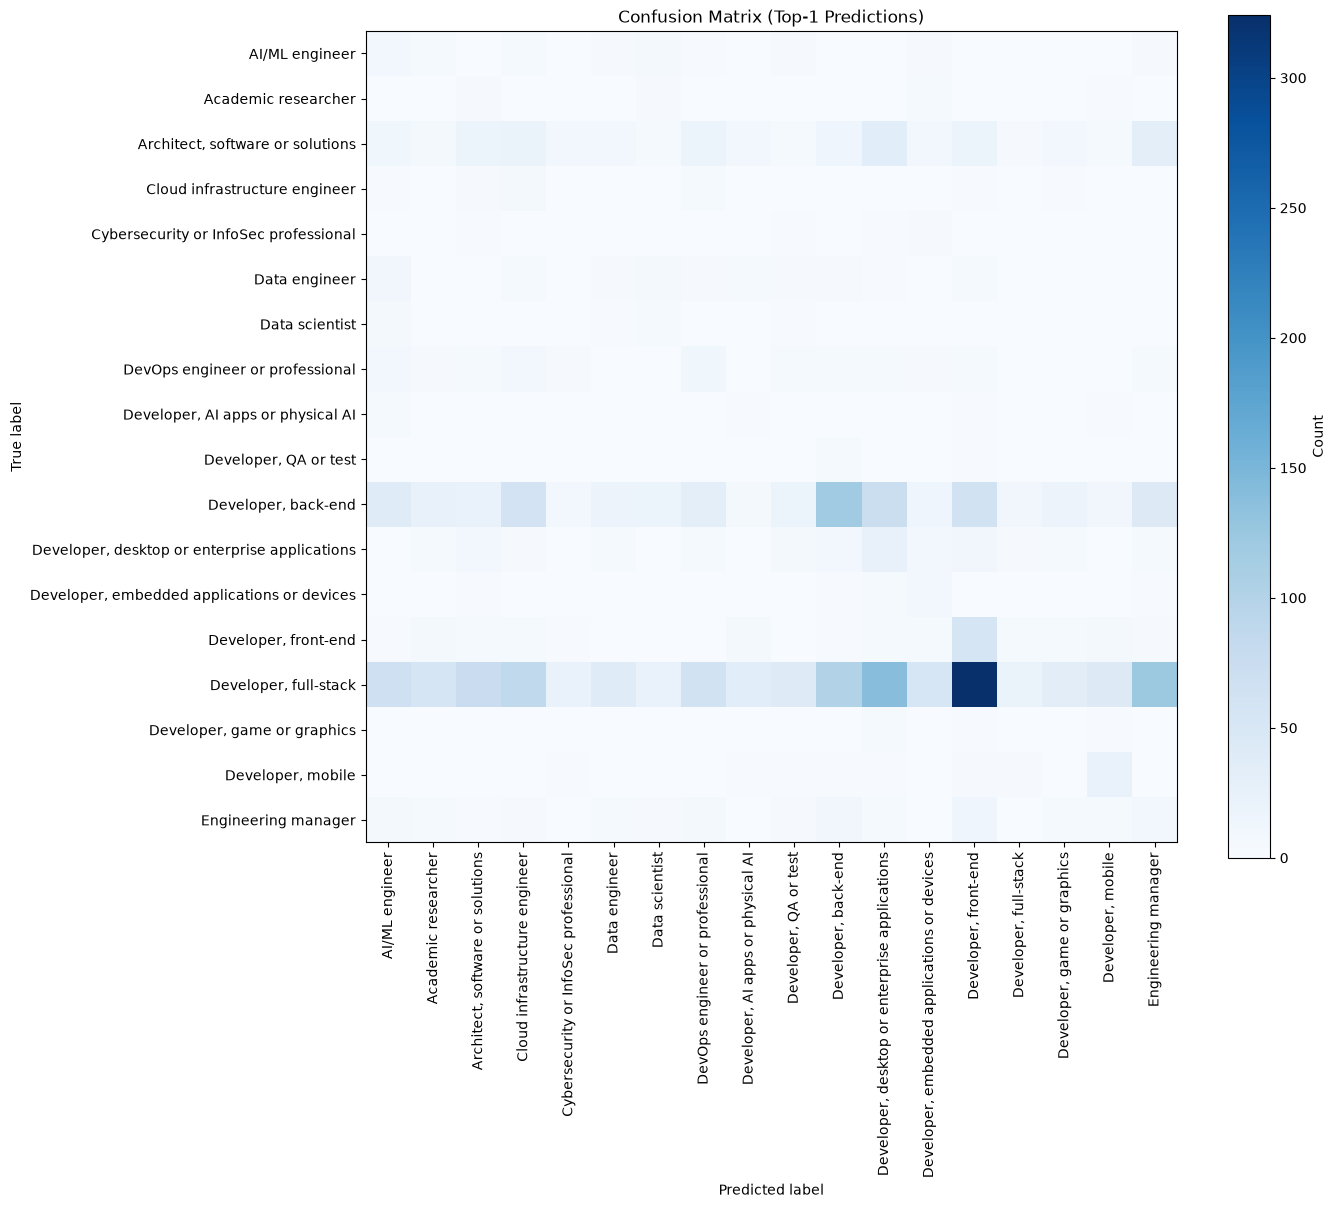

Confusion matrix saved to confusion_matrix.png


In [225]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

class_order = sorted(set(true_labels))
cm = confusion_matrix(true_labels, top1_predictions, labels=class_order)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(class_order)))
ax.set_yticks(range(len(class_order)))
ax.set_xticklabels(class_order, rotation=90)
ax.set_yticklabels(class_order)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix (Top-1 Predictions)')

fig.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved to confusion_matrix.png")

**72.29% top-5 accuracy sounds good in isolation, but it needs a baseline comparison to know if it's actually good.** Two trivial, non-personalized baselines:

1. **Naive top-1**: always predict the single most common training class for every test row, regardless of input.
2. **Naive top-5**: always show the 5 most common training classes for every test row, regardless of input.

If the real model doesn't clearly beat these, it isn't actually learning to personalize -- it's just riding the base rate.

In [226]:
most_common_class = y_train.value_counts().idxmax()
top5_common_classes = y_train.value_counts().nlargest(5).index.tolist()

naive_top1_hits = (y_test == most_common_class).sum()
naive_top5_hits = y_test.isin(top5_common_classes).sum()

naive_top1_acc = naive_top1_hits / len(y_test)
naive_top5_acc = naive_top5_hits / len(y_test)

print(f"Most common training class: {most_common_class}")
print(f"Top 5 most common training classes: {top5_common_classes}\n")

print(f"{'Metric':10s} {'Naive baseline':>16s} {'Real model':>16s}")
print(f"{'Top-1':10s} {naive_top1_acc:>15.2%} {top1_acc:>15.2%}")
print(f"{'Top-5':10s} {naive_top5_acc:>15.2%} {top5_acc:>15.2%}")

Most common training class: Developer, full-stack
Top 5 most common training classes: ['Developer, full-stack', 'Developer, back-end', 'Architect, software or solutions', 'Developer, front-end', 'Developer, desktop or enterprise applications']

Metric       Naive baseline       Real model
Top-1               47.54%          11.23%
Top-5               84.59%          72.29%


If the real model underperforms either baseline -- likely, given `full-stack`'s recall collapsed to 1.6% in the per-class table above -- the cause is the class weighting scheme **overshooting**. Pure inverse-frequency weighting with this much class imbalance (100:1+) can overcorrect so hard that the tree avoids the majority class even when it's correct, since every full-stack mistake now costs almost nothing while every rare-class mistake costs a lot.

The fix is dampening the weight formula with a **square root**, which keeps rare classes weighted higher than common ones but compresses how extreme that gap is:

`weight = sqrt(N / (K * class_count))` instead of the raw `N / (K * class_count)` used before.

In [227]:
dampened_class_weights = {
    cls: np.sqrt(len(y_train) / (num_classes * count))
    for cls, count in class_counts_train.items()
}

sorted_classes = sorted(dampened_class_weights, key=lambda c: dampened_class_weights[c], reverse=True)

print(f"{'Class':55s} {'Old weight':>12s} {'New weight':>12s}")
for cls in sorted_classes:
    print(f"{cls:55s} {class_weights[cls]:>12.4f} {dampened_class_weights[cls]:>12.4f}")

Class                                                     Old weight   New weight
Developer, game or graphics                                  14.1591       3.7629
Cybersecurity or InfoSec professional                        12.4600       3.5299
Developer, QA or test                                        12.2157       3.4951
Developer, AI apps or physical AI                             9.8889       3.1447
Academic researcher                                           9.2985       3.0493
Data scientist                                                7.1609       2.6760
Developer, embedded applications or devices                   6.1078       2.4714
Cloud infrastructure engineer                                 6.1078       2.4714
AI/ML engineer                                                3.7758       1.9431
Developer, mobile                                             3.4231       1.8502
Data engineer                                                 3.1150       1.7649
DevOps engineer 

Rebuilding the entire tree from scratch with these new weights -- same `max_depth=12`, `min_samples_split=10` -- so this is a fair comparison: only the weighting changed, nothing else.

In [228]:
sample_weights_train_dampened = y_train.map(dampened_class_weights).to_numpy()

tree_dampened = build_tree(X_train_arr, y_train_arr, sample_weights_train_dampened, feature_list)

dampened_max_depth, dampened_num_leaves = tree_stats(tree_dampened)
print(f"New tree (dampened weights) - max depth reached: {dampened_max_depth}")
print(f"New tree (dampened weights) - total leaf nodes: {dampened_num_leaves}")
print(f"Original tree (pure inverse-frequency) - max depth reached: {max_depth_reached}, leaves: {num_leaves}")

New tree (dampened weights) - max depth reached: 12
New tree (dampened weights) - total leaf nodes: 654
Original tree (pure inverse-frequency) - max depth reached: 12, leaves: 554


Rerunning the full test-set evaluation from before, on this new tree, to see whether dampening fixed the overcorrection without losing the benefit for rare classes entirely.

In [229]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

# Preserve the original (pure inverse-frequency) results before recomputing
original_top1_acc = top1_acc
original_top5_acc = top5_acc
original_macro_precision = macro_precision
original_macro_recall = macro_recall
original_macro_f1 = macro_f1

true_labels_d = []
top5_predictions_d = []
top1_predictions_d = []

for i in range(len(X_test_arr)):
    sample = X_test_arr[i]
    true_label = y_test.iloc[i]
    top5 = predict_proba(tree_dampened, sample, feature_list)
    true_labels_d.append(true_label)
    top5_predictions_d.append(top5)
    top1_predictions_d.append(top5[0][0])

top1_hits_d = sum(1 for p, t in zip(top1_predictions_d, true_labels_d) if p == t)
top5_hits_d = sum(
    1 for top5, t in zip(top5_predictions_d, true_labels_d)
    if t in [c for c, _ in top5]
)

n_test_d = len(true_labels_d)
top1_acc_d = top1_hits_d / n_test_d
top5_acc_d = top5_hits_d / n_test_d

macro_precision_d, macro_recall_d, macro_f1_d, _ = precision_recall_fscore_support(
    true_labels_d, top1_predictions_d, average='macro', zero_division=0
)

report_d = classification_report(true_labels_d, top1_predictions_d, output_dict=True, zero_division=0)

rows_d = []
for cls in sorted(set(true_labels_d)):
    cls_report = report_d[cls]
    cls_mask = [t == cls for t in true_labels_d]
    cls_true_count = sum(cls_mask)
    cls_top5_hits = sum(
        1 for top5, true, is_cls in zip(top5_predictions_d, true_labels_d, cls_mask)
        if is_cls and true in [c for c, _ in top5]
    )
    top5_hit_rate_d = cls_top5_hits / cls_true_count if cls_true_count else 0.0
    rows_d.append({
        'DevType': cls,
        'support': int(cls_report['support']),
        'precision': cls_report['precision'],
        'recall': cls_report['recall'],
        'f1': cls_report['f1-score'],
        'top5_hit_rate': top5_hit_rate_d,
    })

per_class_df_dampened = pd.DataFrame(rows_d).sort_values('recall', ascending=True).reset_index(drop=True)

print("Per-class table (dampened weights), sorted by recall ascending:")
print(per_class_df_dampened.to_string(index=False))

summary = pd.DataFrame({
    'Naive baseline': [naive_top1_acc, naive_top5_acc, None, None, None],
    'Original weights': [original_top1_acc, original_top5_acc, original_macro_precision,
                          original_macro_recall, original_macro_f1],
    'Dampened weights': [top1_acc_d, top5_acc_d, macro_precision_d, macro_recall_d, macro_f1_d],
}, index=['Top-1 acc', 'Top-5 acc', 'Macro precision', 'Macro recall', 'Macro F1'])

print("\nSummary comparison -- naive baseline vs original weights vs dampened weights:")
print(summary.round(4).to_string())

Per-class table (dampened weights), sorted by recall ascending:
                                      DevType  support  precision   recall       f1  top5_hit_rate
                          Academic researcher       17   0.000000 0.000000 0.000000       0.058824
        Cybersecurity or InfoSec professional       13   0.000000 0.000000 0.000000       0.153846
                  Developer, game or graphics       11   0.000000 0.000000 0.000000       0.000000
            Developer, AI apps or physical AI       16   0.025641 0.062500 0.036364       0.250000
              DevOps engineer or professional       70   0.084746 0.071429 0.077519       0.485714
                          Engineering manager       83   0.089744 0.084337 0.086957       0.542169
Developer, desktop or enterprise applications       98   0.120482 0.102041 0.110497       0.653061
                Cloud infrastructure engineer       26   0.078947 0.115385 0.093750       0.384615
                                Data engineer

**Extracting the confusion matrix's most useful signal as a readable table**, rather than eyeballing a heatmap: for each true `DevType` class, which *other* class does it get predicted as most often when the model is wrong?

This distinguishes two very different explanations for a low ceiling: if misclassifications concentrate on closely related roles (e.g. full-stack confused with back-end/front-end), that's expected label overlap in self-reported survey data, not a flaw in the tree. If they scatter across unrelated roles instead, that points to a real, fixable modeling problem.

In [230]:
from sklearn.metrics import confusion_matrix

class_order_d = sorted(set(true_labels_d))
cm_d = confusion_matrix(true_labels_d, top1_predictions_d, labels=class_order_d)

confusion_rows = []
for i, true_cls in enumerate(class_order_d):
    row = cm_d[i]
    total_errors = row.sum() - row[i]
    if total_errors == 0:
        continue
    row_no_diag = row.copy()
    row_no_diag[i] = 0
    max_j = row_no_diag.argmax()
    confusion_rows.append({
        'true_class': true_cls,
        'most_common_wrong_guess': class_order_d[max_j],
        'pct_of_errors': row_no_diag[max_j] / total_errors,
        'total_errors': int(total_errors),
    })

confusion_summary = pd.DataFrame(confusion_rows).sort_values('pct_of_errors', ascending=False).reset_index(drop=True)
print(confusion_summary.to_string(index=False))

                                   true_class                     most_common_wrong_guess  pct_of_errors  total_errors
                         Developer, front-end                       Developer, full-stack       0.729730            74
                        Developer, QA or test                       Developer, full-stack       0.600000            10
                          Developer, back-end                       Developer, full-stack       0.578313           415
                  Developer, game or graphics                       Developer, full-stack       0.545455            11
                          Academic researcher                       Developer, full-stack       0.529412            17
Developer, desktop or enterprise applications                       Developer, full-stack       0.431818            88
                          Engineering manager                       Developer, full-stack       0.407895            76
            Developer, AI apps or physical AI   

Also worth checking: the dampened model's top-5 accuracy (84.59%) matched the naive baseline's top-5 accuracy (84.59%) exactly at 2 decimal places above. Printing the raw counts to more precision confirms whether this is a genuine exact tie or just a rounding coincidence.

In [231]:
print(f"Naive top-5:    {naive_top5_hits}/{len(y_test)} = {naive_top5_acc:.10f}")
print(f"Dampened top-5: {top5_hits_d}/{n_test_d} = {top5_acc_d:.10f}")
print(f"Exact match: {naive_top5_hits == top5_hits_d and len(y_test) == n_test_d}")

Naive top-5:    2372/2804 = 0.8459343795
Dampened top-5: 2372/2804 = 0.8459343795
Exact match: True


**Testing one middle-ground weight exponent (0.7)**, between the 0.5 (sqrt) already tried and the 1.0 (raw inverse-frequency) that overcorrected, to see if it beats both the sqrt result and the naive baseline without running a full hyperparameter search.

In [232]:
exp_class_weights = {
    cls: (len(y_train) / (num_classes * count)) ** 0.7
    for cls, count in class_counts_train.items()
}

sample_weights_train_exp = y_train.map(exp_class_weights).to_numpy()
tree_exp = build_tree(X_train_arr, y_train_arr, sample_weights_train_exp, feature_list)

exp_max_depth, exp_num_leaves = tree_stats(tree_exp)
print(f"New tree (exponent 0.7) - max depth reached: {exp_max_depth}, leaves: {exp_num_leaves}\n")

true_labels_e = []
top5_predictions_e = []
top1_predictions_e = []

for i in range(len(X_test_arr)):
    sample = X_test_arr[i]
    true_label = y_test.iloc[i]
    top5 = predict_proba(tree_exp, sample, feature_list)
    true_labels_e.append(true_label)
    top5_predictions_e.append(top5)
    top1_predictions_e.append(top5[0][0])

top1_hits_e = sum(1 for p, t in zip(top1_predictions_e, true_labels_e) if p == t)
top5_hits_e = sum(
    1 for top5, t in zip(top5_predictions_e, true_labels_e)
    if t in [c for c, _ in top5]
)

n_test_e = len(true_labels_e)
top1_acc_e = top1_hits_e / n_test_e
top5_acc_e = top5_hits_e / n_test_e

macro_precision_e, macro_recall_e, macro_f1_e, _ = precision_recall_fscore_support(
    true_labels_e, top1_predictions_e, average='macro', zero_division=0
)

summary_all = pd.DataFrame({
    'Naive baseline': [naive_top1_acc, naive_top5_acc, None, None, None],
    'Original (exp=1.0)': [original_top1_acc, original_top5_acc, original_macro_precision,
                            original_macro_recall, original_macro_f1],
    'Dampened (exp=0.5)': [top1_acc_d, top5_acc_d, macro_precision_d, macro_recall_d, macro_f1_d],
    'Exponent=0.7': [top1_acc_e, top5_acc_e, macro_precision_e, macro_recall_e, macro_f1_e],
}, index=['Top-1 acc', 'Top-5 acc', 'Macro precision', 'Macro recall', 'Macro F1'])

print("Summary comparison -- naive baseline vs exp=1.0 vs exp=0.5 vs exp=0.7:")
print(summary_all.round(4).to_string())

New tree (exponent 0.7) - max depth reached: 12, leaves: 579

Summary comparison -- naive baseline vs exp=1.0 vs exp=0.5 vs exp=0.7:
                 Naive baseline  Original (exp=1.0)  Dampened (exp=0.5)  Exponent=0.7
Top-1 acc                0.4754              0.1123              0.3905        0.3117
Top-5 acc                0.8459              0.7229              0.8459        0.8292
Macro precision             NaN              0.1015              0.1406        0.1343
Macro recall                NaN              0.1803              0.1607        0.1914
Macro F1                    NaN              0.0935              0.1445        0.1389


**Testing the fallback-dilution hypothesis.** The leaf fallback built earlier (borrowing from ancestor nodes when a leaf has fewer than 5 classes) may be diluting most predictions toward population-level defaults, since ancestor nodes closer to the root look increasingly like the overall class distribution -- dominated by full-stack, back-end, architect, front-end, and desktop/enterprise, the same 5 classes in the naive baseline.

If most test predictions require heavy fallback borrowing, that would explain both the exact tie with the naive top-5 baseline and `full-stack` appearing as the most common wrong guess across nearly every class. This uses the dampened-weight tree (`tree_dampened`), since that's the one that produced the exact tie.

In [233]:
def predict_proba_diagnostic(tree, sample, feature_list, top_k=5, borrow_factor=0.4):
    node = tree
    path = [node]
    while not node.is_leaf():
        j = feature_list.index(node.feature)
        value = sample[j]
        node = node.left if value <= node.threshold else node.right
        path.append(node)

    leaf = path[-1]
    combined = dict(leaf.class_distribution)
    leaf_class_count = len(combined)
    levels_needed = 0

    if len(combined) < top_k:
        for ancestor in reversed(path[:-1]):
            if len(combined) >= top_k:
                break
            levels_needed += 1
            for cls, p in ancestor.class_distribution.items():
                if cls not in combined:
                    combined[cls] = p * borrow_factor

    ranked = sorted(combined.items(), key=lambda kv: kv[1], reverse=True)[:top_k]
    return ranked, leaf_class_count, levels_needed


leaf_class_counts = []
levels_needed_list = []
top5_diag = []

for i in range(len(X_test_arr)):
    sample = X_test_arr[i]
    ranked, leaf_count, levels = predict_proba_diagnostic(tree_dampened, sample, feature_list)
    leaf_class_counts.append(leaf_count)
    levels_needed_list.append(levels)
    top5_diag.append(ranked)

leaf_class_counts = np.array(leaf_class_counts)
levels_needed_arr = np.array(levels_needed_list)
no_fallback_mask = leaf_class_counts >= 5

pct_no_fallback = no_fallback_mask.mean()
print(f"Predictions needing zero fallback (leaf alone had 5+ classes): {pct_no_fallback:.2%}")

fallback_levels = levels_needed_arr[~no_fallback_mask]
print(f"Predictions needing fallback: {(~no_fallback_mask).mean():.2%}\n")

print("Distribution of ancestor-levels-needed among fallback predictions:")
level_counts = pd.Series(fallback_levels).value_counts().sort_index()
for lvl, cnt in level_counts.items():
    print(f"  {lvl} level(s) up: {cnt} ({cnt / len(fallback_levels):.2%} of fallback cases)")

Predictions needing zero fallback (leaf alone had 5+ classes): 72.43%
Predictions needing fallback: 27.57%

Distribution of ancestor-levels-needed among fallback predictions:
  1 level(s) up: 396 (51.23% of fallback cases)
  2 level(s) up: 190 (24.58% of fallback cases)
  3 level(s) up: 123 (15.91% of fallback cases)
  4 level(s) up: 48 (6.21% of fallback cases)
  5 level(s) up: 15 (1.94% of fallback cases)
  7 level(s) up: 1 (0.13% of fallback cases)


**Direct test**: if the fallback is the cause, predictions that didn't need it (leaf alone had enough classes) should show meaningfully better top-5 accuracy than predictions that needed heavy borrowing, since only the non-fallback ones reflect genuine leaf-level personalization rather than borrowed population averages.

In [234]:
no_fallback_hits, no_fallback_total = 0, 0
fallback_hits, fallback_total = 0, 0

for i in range(len(X_test_arr)):
    true_label = y_test.iloc[i]
    hit = true_label in [c for c, _ in top5_diag[i]]

    if no_fallback_mask[i]:
        no_fallback_total += 1
        no_fallback_hits += hit
    else:
        fallback_total += 1
        fallback_hits += hit

no_fallback_acc = no_fallback_hits / no_fallback_total if no_fallback_total else float('nan')
fallback_acc = fallback_hits / fallback_total if fallback_total else float('nan')

print(f"No fallback needed: {no_fallback_total} rows, top-5 accuracy = {no_fallback_acc:.2%}")
print(f"Fallback needed:    {fallback_total} rows, top-5 accuracy = {fallback_acc:.2%}")

No fallback needed: 2031 rows, top-5 accuracy = 85.33%
Fallback needed:    773 rows, top-5 accuracy = 82.66%


**Checking whether the tree's own splits -- not the fallback -- are converging toward population defaults.** For predictions that never touched the fallback (leaf alone had 5+ classes), how often is that leaf's own top-5 ranking identical to the naive baseline's fixed 5 classes? And where not identical, how much overlap is there typically? This confirms or rules out whether the tree's actual split structure is what's converging toward population-level defaults, now that the fallback mechanism has been ruled out as the primary cause.

In [235]:
naive_set = set(top5_common_classes)

exact_match_count = 0
overlap_counts = []

for i in range(len(X_test_arr)):
    if not no_fallback_mask[i]:
        continue
    leaf_top5_classes = set(c for c, _ in top5_diag[i])
    overlap_counts.append(len(leaf_top5_classes & naive_set))
    if leaf_top5_classes == naive_set:
        exact_match_count += 1

no_fallback_total_check = len(overlap_counts)
exact_match_pct = exact_match_count / no_fallback_total_check
avg_overlap = np.mean(overlap_counts)

print(f"No-fallback rows: {no_fallback_total_check}")
print(f"Leaf's top-5 exactly matches naive baseline's top-5: {exact_match_count}/{no_fallback_total_check} = {exact_match_pct:.2%}")
print(f"Average overlap between leaf top-5 and naive top-5: {avg_overlap:.2f} / 5 classes")

No-fallback rows: 2031
Leaf's top-5 exactly matches naive baseline's top-5: 247/2031 = 12.16%
Average overlap between leaf top-5 and naive top-5: 3.49 / 5 classes


**Testing depth, not weighting, as the next lever.** The root split only achieved a small weighted impurity reduction (0.0119), and `YearsCode` was already shown earlier to mainly separate management/architect tracks from individual-contributor roles, not between IC roles themselves. With only 12 levels of splitting, many leaves may not accumulate enough separation to demote population-level favorites out of the top 5, even while still improving per-class recall at the margins.

This rebuilds the tree with `max_depth=20` (up from 12), keeping the dampened (sqrt) weighting scheme -- the best performer so far on top-1, top-5, and macro F1. Deeper trees risk overfitting, so this evaluates on **both** the training set and test set, watching for a growing gap between them as a warning sign, not just chasing a higher test number in isolation.

In [236]:
tree_deep = build_tree(
    X_train_arr, y_train_arr, sample_weights_train_dampened, feature_list,
    max_depth=20, min_samples_split=10
)

deep_max_depth, deep_num_leaves = tree_stats(tree_deep)
print(f"New tree (max_depth=20) - depth reached: {deep_max_depth}, leaves: {deep_num_leaves}\n")


def evaluate_full(tree, X_arr, y_series, feature_list):
    true_l = []
    top1_l = []
    top5_hit = 0
    for i in range(len(X_arr)):
        sample = X_arr[i]
        true_label = y_series.iloc[i]
        top5 = predict_proba(tree, sample, feature_list)
        true_l.append(true_label)
        top1_l.append(top5[0][0])
        if true_label in [c for c, _ in top5]:
            top5_hit += 1
    n = len(true_l)
    top1_acc = sum(1 for p, t in zip(top1_l, true_l) if p == t) / n
    top5_acc = top5_hit / n
    _, _, macro_f1_val, _ = precision_recall_fscore_support(true_l, top1_l, average='macro', zero_division=0)
    return top1_acc, top5_acc, macro_f1_val


train_top1, train_top5, train_f1 = evaluate_full(tree_deep, X_train_arr, y_train, feature_list)
test_top1, test_top5, test_f1 = evaluate_full(tree_deep, X_test_arr, y_test, feature_list)

comp = pd.DataFrame({
    'Train': [train_top1, train_top5, train_f1],
    'Test': [test_top1, test_top5, test_f1],
}, index=['Top-1 acc', 'Top-5 acc', 'Macro F1'])
print(comp.round(4).to_string())

gap_top1 = train_top1 - test_top1
gap_top5 = train_top5 - test_top5
print()
if gap_top1 > 0.15 or gap_top5 > 0.15:
    print(f"WARNING: large train/test gap detected (top-1 gap={gap_top1:.2%}, top-5 gap={gap_top5:.2%}) "
          "-- this looks like overfitting, not genuine improvement.")
else:
    print(f"Train/test gap is modest (top-1 gap={gap_top1:.2%}, top-5 gap={gap_top5:.2%}) "
          "-- no strong overfitting signal.")

New tree (max_depth=20) - depth reached: 20, leaves: 1800

            Train    Test
Top-1 acc  0.6593  0.3331
Top-5 acc  0.9932  0.8466
Macro F1   0.5895  0.1344



**`min_samples_split` has been fixed at 10 through every experiment so far** -- three weighting schemes and two depths -- while it's arguably the more direct lever against the overfitting just diagnosed. At depth 20, 1,800 leaves across ~11,000 training rows average roughly 6 rows per leaf, too few to represent a stable pattern rather than noise.

Since going deeper (smaller leaves) made results worse, this tests the opposite direction: keep `max_depth=12` (the best depth so far) and require substantially larger leaves before splitting is allowed, using the dampened (sqrt) weighting scheme that had the best test macro F1 so far.

In [237]:
min_samples_split_values = [10, 30, 50]
mss_results = {}

for mss in min_samples_split_values:
    t = build_tree(
        X_train_arr, y_train_arr, sample_weights_train_dampened, feature_list,
        max_depth=12, min_samples_split=mss
    )
    depth_reached, leaves = tree_stats(t)
    train_top1, train_top5, train_f1 = evaluate_full(t, X_train_arr, y_train, feature_list)
    test_top1, test_top5, test_f1 = evaluate_full(t, X_test_arr, y_test, feature_list)

    mss_results[mss] = {
        'tree': t, 'depth_reached': depth_reached, 'leaves': leaves,
        'train_top1': train_top1, 'test_top1': test_top1,
        'train_top5': train_top5, 'test_top5': test_top5,
        'train_f1': train_f1, 'test_f1': test_f1,
    }

comparison = pd.DataFrame({
    f"min_samples_split={mss}": [
        mss_results[mss]['depth_reached'], mss_results[mss]['leaves'],
        mss_results[mss]['train_top1'], mss_results[mss]['test_top1'],
        mss_results[mss]['train_top5'], mss_results[mss]['test_top5'],
        mss_results[mss]['train_f1'], mss_results[mss]['test_f1'],
    ]
    for mss in min_samples_split_values
}, index=['Depth reached', 'Leaf count', 'Train Top-1', 'Test Top-1',
          'Train Top-5', 'Test Top-5', 'Train Macro F1', 'Test Macro F1'])

print(comparison.round(4).to_string())

                min_samples_split=10  min_samples_split=30  min_samples_split=50
Depth reached                12.0000               12.0000               12.0000
Leaf count                  654.0000              386.0000              302.0000
Train Top-1                   0.5220                0.4694                0.4551
Test Top-1                    0.3905                0.3802                0.3816
Train Top-5                   0.9464                0.9314                0.9223
Test Top-5                    0.8459                0.8409                0.8438
Train Macro F1                0.4172                0.3288                0.2996
Test Macro F1                 0.1445                0.1568                0.1627


**What to look for**: ideally a `min_samples_split` value where the train-test gap has narrowed compared to the depth-20 result, *and* test macro F1 or top-5 accuracy has improved over the current best (depth-12, dampened weights, `min_samples_split=10`: test top-5 84.59%, test macro F1 0.1445). If the gap narrows without metrics improving, that's still useful information -- it would mean less overfitting isn't automatically the same as better generalization here.

In [238]:
best_mss = max(min_samples_split_values, key=lambda m: mss_results[m]['test_f1'])
best_f1 = mss_results[best_mss]['test_f1']
best_top5 = mss_results[best_mss]['test_top5']

current_best_f1 = macro_f1_d
current_best_top5 = top5_acc_d

beats_naive_top5 = best_top5 > naive_top5_acc
beats_current_best_f1 = best_f1 > current_best_f1

print(f"Best min_samples_split by test macro F1: {best_mss} "
      f"(test macro F1 = {best_f1:.4f}, test top-5 = {best_top5:.2%})")
print(f"Beats naive baseline top-5 ({naive_top5_acc:.2%}): {beats_naive_top5}")
print(f"Beats current best test macro F1 ({current_best_f1:.4f}, min_samples_split=10): {beats_current_best_f1}")

Best min_samples_split by test macro F1: 50 (test macro F1 = 0.1627, test top-5 = 84.38%)
Beats naive baseline top-5 (84.59%): False
Beats current best test macro F1 (0.1445, min_samples_split=10): True


**Locking in the final configuration**: `max_depth=12`, `min_samples_split=50`, dampened (sqrt) class weighting.

The metrics already produced for this configuration in the sweep above -- **test top-5: 84.38%, test macro F1: 0.1627** -- are the official results to cite in the report. Nothing after this point should be re-reported as a new result; the steps below are about preparing the model for actual use, not further evaluation.

In [239]:
import pickle
import json as json_module
import os
import sys
from datetime import date

sys.path.insert(0, os.path.join('..'))
from predictions.ml.tree_model import Node as DeploymentNode

# Rebind the global Node used by build_tree to the importable class in predictions/ml/tree_model.py,
# so the pickled tree can be loaded outside this notebook (pickle stores classes by module path,
# and a class defined inline in a notebook cell lives in '__main__', which doesn't exist elsewhere).
Node = DeploymentNode

final_class_weights = dampened_class_weights
final_tree = build_tree(
    X_train_arr, y_train_arr, sample_weights_train_dampened, feature_list,
    max_depth=12, min_samples_split=50
)

ml_dir = os.path.join('..', 'predictions', 'ml')
os.makedirs(ml_dir, exist_ok=True)

model_path = os.path.join(ml_dir, 'career_tree.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(final_tree, f)

metadata = {
    'hyperparameters': {
        'max_depth': 12,
        'min_samples_split': 50,
        'class_weighting': 'sqrt-dampened inverse frequency',
    },
    'test_metrics': {
        'top1_accuracy': 0.3816,
        'top5_accuracy': 0.8438,
        'macro_f1': 0.1627,
    },
    'date_trained': str(date.today()),
}

metadata_path = os.path.join(ml_dir, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json_module.dump(metadata, f, indent=2)

print(f"Model saved to {model_path}")
print(f"Metadata saved to {metadata_path}")
print(f"\nMetadata contents:")
print(json_module.dumps(metadata, indent=2))

Model saved to ../predictions/ml/career_tree.pkl
Metadata saved to ../predictions/ml/model_metadata.json

Metadata contents:
{
  "hyperparameters": {
    "max_depth": 12,
    "min_samples_split": 50,
    "class_weighting": "sqrt-dampened inverse frequency"
  },
  "test_metrics": {
    "top1_accuracy": 0.3816,
    "top5_accuracy": 0.8438,
    "macro_f1": 0.1627
  },
  "date_trained": "2026-08-15"
}


**Retraining on the full dataset for deployment** -- this is standard practice, not new experimentation. The train/test split's job was choosing honest hyperparameters and getting an unbiased performance estimate, and that job is done. Retraining the same locked configuration on **all** available cleaned data (train + test combined) before shipping gives the deployed model more real examples to learn from, at zero methodological cost, since no further evaluation claims will be made about this version.

In [240]:
X_full_arr = np.concatenate([X_train_arr, X_test_arr], axis=0)
y_full_arr = np.concatenate([y_train_arr, y_test.to_numpy()], axis=0)
y_full_series = pd.Series(y_full_arr)

full_class_counts = y_full_series.value_counts()
full_num_classes = len(full_class_counts)

final_class_weights_full = {
    cls: np.sqrt(len(y_full_series) / (full_num_classes * count))
    for cls, count in full_class_counts.items()
}

sample_weights_full = y_full_series.map(final_class_weights_full).to_numpy()

deployment_tree = build_tree(
    X_full_arr, y_full_arr, sample_weights_full, feature_list,
    max_depth=12, min_samples_split=50
)

model_path = os.path.join('..', 'predictions', 'ml', 'career_tree.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(deployment_tree, f)

file_size_kb = os.path.getsize(model_path) / 1024

print(f"Deployment model saved to {model_path}")
print(f"File size: {file_size_kb:.1f} KB")
print(f"Trained on {len(y_full_arr)} total rows (train + test combined)")
print("\nReminder: this version's performance should not be re-evaluated or re-reported -- "
      "the honest numbers already came from the train/test split above (test top-5: 84.38%, test macro F1: 0.1627).")

Deployment model saved to ../predictions/ml/career_tree.pkl
File size: 154.4 KB
Trained on 14018 total rows (train + test combined)

Reminder: this version's performance should not be re-evaluated or re-reported -- the honest numbers already came from the train/test split above (test top-5: 84.38%, test macro F1: 0.1627).


**`predict_proba` needs the exact ordered list of the 145 feature column names** to map a new student's raw inputs into the same array shape the tree was trained on -- this wasn't saved alongside the model yet, and needs to be before this notebook's kernel state is the only place it exists.

The full column names are saved as-is (e.g. `LanguageHaveWorkedWith__Python`), not stripped -- this also documents every valid raw skill value for whoever builds the student-facing form later, since the value after `__` is exactly what needs to appear as a checkbox option.

In [241]:
metadata_path = os.path.join('..', 'predictions', 'ml', 'model_metadata.json')

with open(metadata_path, 'r') as f:
    metadata = json_module.load(f)

metadata['feature_list'] = X.columns.tolist()

with open(metadata_path, 'w') as f:
    json_module.dump(metadata, f, indent=2)

print(f"Keys now in {metadata_path}:")
print(list(metadata.keys()))
print(f"\nfeature_list length: {len(metadata['feature_list'])}")

Keys now in ../predictions/ml/model_metadata.json:
['hyperparameters', 'test_metrics', 'date_trained', 'feature_list']

feature_list length: 144
